In [1]:
import os
import numpy as np
import pandas as pd
import scanpy as sc
import loompy as lp
import matplotlib.pyplot as plt
import seaborn as sns
import json
import base64
import zlib
from scipy.stats import spearmanr
from statsmodels.stats.multitest import multipletests
from scipy.stats import mannwhitneyu
import matplotlib.colors as mcolors

# pySCENIC output: 
https://github.com/aertslab/SCENICprotocol 

* The original expression matrix
* The pySCENIC-specific results:
    * Regulons (TFs and their target genes)
    * AUCell matrix (cell enrichment scores for each regulon)
    * Dimensionality reduction embeddings based on the AUCell matrix (t-SNE, UMAP)
* Results from the parallel best-practices analysis using highly variable genes:
    * Dimensionality reduction embeddings (t-SNE, UMAP)
    * Louvain clustering annotations


In [ ]:
#loom_output = '../outputs/CCG1106_084_T1_pyscenic_output.loom'
#sample_name = 'CCG1106_084_T1'
loom_output = '../outputs/CCG1106_075_T1_pyscenic_output.loom'
sample_name = 'CCG1106_075_T1'

# extract relevant data
lf = lp.connect(loom_output, mode='r', validate=False )
meta = json.loads(zlib.decompress(base64.b64decode( lf.attrs.MetaData )))
exprMat = pd.DataFrame( lf[:,:], index=lf.ra.Gene, columns=lf.ca.CellID).T
auc_mtx = pd.DataFrame( lf.ca.RegulonsAUC, index=lf.ca.CellID)

# program usage by cell
#P = pd.read_csv('../../cnmf_gep_analysis/outputs/cnmf_output_CCG1106_084_T1/CCG1106_084_T1_cNMF/CCG1106_084_T1_cNMF.usages.k_10.dt_0_1.consensus.txt', sep='\t', index_col=0)
P = pd.read_csv('../../cnmf_gep_analysis/outputs/cnmf_output_CCG1106_075_T1/CCG1106_075_T1_cNMF/CCG1106_075_T1_cNMF.usages.k_4.dt_0_1.consensus.txt', sep='\t', index_col=0)
auc_mtx.head()

,ALX3(+),ALX4(+),ARID3A(+),ATF1(+),ATF2(+),ATF3(+),ATF4(+),ATF6B(+),ATF7(+),BACH1(+),...,ZNF780A(+),ZNF814(+),ZNF83(+),ZNF837(+),ZNF90(+),ZNF93(+),ZSCAN2(+),ZSCAN23(+),ZSCAN26(+),ZSCAN9(+)
GGTATTGGTTCCGTCT,0.000000,0.005523,0.0,0.000000,0.114891,0.000000,0.025334,0.077627,0.000000,0.074151,...,0.0,0.0,0.022609,0.0,0.000000,0.0,0.03508,0.025227,0.000000,0.0
TGCCCTACAGGCAGTA,0.000000,0.001062,0.0,0.000000,0.102350,0.000000,0.035769,0.009658,0.021383,0.077755,...,0.0,0.0,0.027018,0.0,0.000000,0.0,0.00000,0.000000,0.000000,0.0
CAACCAATCAGTTAGC,0.006373,0.000000,0.0,0.000000,0.090000,0.005864,0.025635,0.020182,0.000000,0.075310,...,0.0,0.0,0.033991,0.0,0.000000,0.0,0.04434,0.000000,0.004036,0.0
CCTAAAGGTCGCCATG,0.014021,0.016862,0.0,0.000000,0.065110,0.000000,0.022114,0.000000,0.016578,0.077055,...,0.0,0.0,0.026863,0.0,0.000000,0.0,0.00000,0.000000,0.000000,0.0
CCTCTGAGTTGTCGCG,0.000000,0.004860,0.0,0.014183,0.108260,0.000818,0.016704,0.066095,0.000000,0.069347,...,0.0,0.0,0.029272,0.0,0.020686,0.0,0.03330,0.000000,0.000000,0.0


# Find correlations between regulon activity and program usage across cells

In [3]:
# Align cells
common = auc_mtx.index.intersection(P.index)
auc = auc_mtx.loc[common]
prog = P.loc[common]

# print how many cells are only in one of the two
print(len(auc_mtx.index) - len(common))
print(len(P.index) - len(common))

# Filter regulons:
frac_nonzero = (auc > 0).mean(axis=0)
var_auc = auc.var(axis=0)

keep = (
    (frac_nonzero >= 0.05) & (frac_nonzero <= 0.95) &
    (var_auc >= var_auc.quantile(0.50))
)
auc_f = auc.loc[:, keep]

# z-score regulons
auc_f = (auc_f - auc_f.mean(axis=0)) / auc_f.std(axis=0, ddof=0)

# Correlate each regulon with each program (Spearman)
rows = []
for program in prog.columns:
    x = prog[program].to_numpy()
    for regulon in auc_f.columns:
        r, p = spearmanr(x, auc_f[regulon].to_numpy(), nan_policy="omit")
        rows.append((program, regulon, r, p))

res = pd.DataFrame(rows, columns=["program", "regulon", "spearman_r", "pval"])

# FDR per program
res["qval"] = np.nan
for program in res["program"].unique():
    m = res["program"].eq(program)
    res.loc[m, "qval"] = multipletests(res.loc[m, "pval"], method="fdr_bh")[1]

0
0


In [4]:
sig = res.query("qval < 0.05").copy()

top_pos = (sig.sort_values(["program", "spearman_r"], ascending=[True, False])
             .groupby("program", as_index=False)
             .head(30))

# save top regulons correlated with programs
top_pos.to_csv(f'../outputs/{sample_name}_top_regulons_per_program.csv', index=False)

# Find dominant program per cell and then top regulons per program

In [5]:
auc0 = auc_mtx.copy()
auc0.index = auc0.index.astype(str)

U = P.copy()

# normalize each cell's usage to sum to 1
U_frac = U.div(U.sum(axis=1), axis=0)

# dominance stats
max_prog = U_frac.idxmax(axis=1)
max_val = U_frac.max(axis=1)
second_val = U_frac.apply(lambda r: np.partition(r.to_numpy(), -2)[-2], axis=1)
ratio = max_val / (second_val + 1e-9)

# pick confident cells
conf = (max_val >= 0.6) & (ratio >= 1.5)

dom = pd.DataFrame({
    "dominant_program": max_prog,
    "max_usage": max_val,
    "second_usage": second_val,
    "max_to_second": ratio,
    "confident": conf
}, index=U.index)

dom_conf = dom[dom["confident"]].copy()
dom_conf = dom_conf[dom_conf["dominant_program"].isin(['1', '2', '3', '4'])].copy()
dom_conf.to_csv(f"../outputs/{sample_name}_dominant_program_confident_cells.csv", index=True)

print("confident cells:", dom_conf.shape[0], "out of", dom.shape[0])
print(dom_conf["dominant_program"].value_counts())

dom["max_usage"].describe()

confident cells: 1805 out of 1955
dominant_program
1    1286
2     274
3     175
4      70
Name: count, dtype: int64


count    1955.000000
mean        0.851657
std         0.137242
min         0.349702
25%         0.772099
50%         0.896550
75%         0.960724
max         1.000000
Name: max_usage, dtype: float64

In [6]:
# Align AUC to confident cells
cells = dom_conf.index.intersection(auc0.index)
auc_c = auc0.loc[cells]
labels = dom_conf.loc[cells, "dominant_program"]

rows = []
for prog in labels.unique():
    in_prog = labels == prog
    for r in auc_c.columns:
        p = mannwhitneyu(auc_c.loc[in_prog, r], auc_c.loc[~in_prog, r], alternative="two-sided").pvalue
        delta = auc_c.loc[in_prog, r].mean() - auc_c.loc[~in_prog, r].mean()
        rows.append((prog, r, delta, p))

de = pd.DataFrame(rows, columns=["program", "regulon", "delta_mean_auc", "pval"])
de["qval"] = de.groupby("program")["pval"].transform(lambda x: multipletests(x, method="fdr_bh")[1])

top_reg = (de.query("qval < 0.05")
             .sort_values(["program", "delta_mean_auc"], ascending=[True, False])
             .groupby("program")
             .head(30))

top_reg.to_csv(f"../outputs/{sample_name}_dominantProgram_top_regulons.csv", index=False)

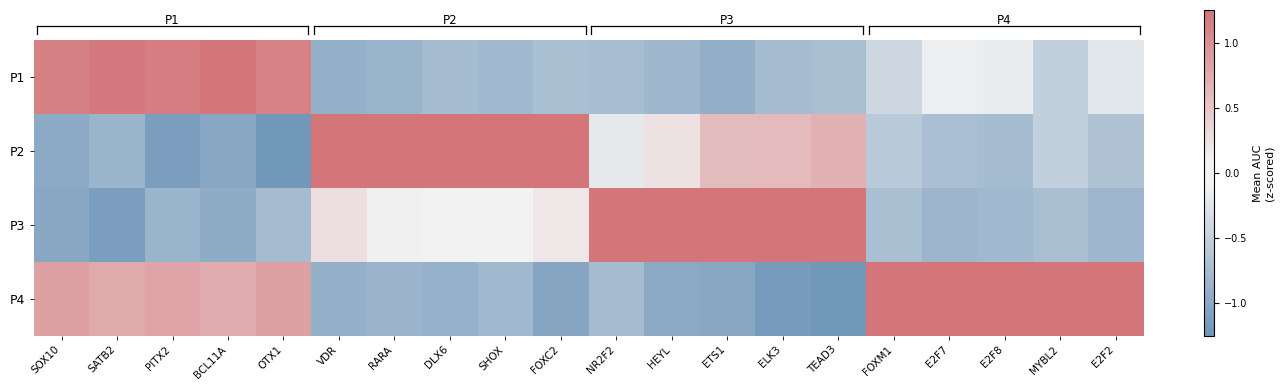

In [7]:
# figure for paper
if sample_name == 'CCG1106_075_T1':
    selected = {
        '1': ['SOX10(+)', 'SATB2(+)', 'PITX2(+)', 'BCL11A(+)', 'OTX1(+)'],
        '2': ['VDR(+)', 'RARA(+)', 'DLX6(+)', 'SHOX(+)', 'FOXC2(+)'],
        '3': ['NR2F2(+)', 'HEYL(+)', 'ETS1(+)', 'ELK3(+)', 'TEAD3(+)'],
        '4': ['FOXM1(+)', 'E2F7(+)', 'E2F8(+)', 'MYBL2(+)', 'E2F2(+)'],
    }
if sample_name == 'CCG1106_084_T1':
    selected = {
        '1': ['PAX7(+)', 'SATB2(+)', 'LIN28B(+)', 'PITX2(+)', 'SOX9(+)'],
        '2': ['HMGA2(+)', 'NR2F1(+)', 'FOSL1(+)' ,'ZNF217(+)', 'KLF6(+)'],
        '3': ['MITF(+)', 'MAFB(+)', 'ZEB1(+)', 'FLI1(+)', 'VDR(+)'],
        '4': ['EBF2(+)', 'NR2F2(+)', 'GATA2(+)', 'TBX5(+)', 'NFATC4(+)'],
    }

all_regulons = [r for regs in selected.values() for r in regs]
cells = dom_conf.index.intersection(auc0.index)
auc_c  = auc0.loc[cells, all_regulons]
labels = dom_conf.loc[cells, "dominant_program"].astype(str)

# Mean AUC per program
prog_labels_simple = {'1': 'P1', '2': 'P2', '3': 'P3', '4': 'P4'}
programs = prog_labels_simple.keys()
mean_auc = pd.DataFrame(
    {prog: auc_c.loc[labels == prog].mean() for prog in programs}
)  # regulons × programs

# z-score each regulon across the 4 programs
z = mean_auc.sub(mean_auc.mean(axis=1), axis=0).div(mean_auc.std(axis=1, ddof=0) + 1e-9, axis=0)

# Order rows
programs_display = ['1', '2', '3', '4']
row_order = []
for prog in programs_display:
    row_order.extend(selected[prog])

z_ordered = z.loc[row_order, programs_display]
clean_labels = [r.replace('(+)', '') for r in row_order]

fig, ax = plt.subplots(figsize=(13, 4))

vmax = 1.25
cmap = sns.diverging_palette(240, 10, s=50, l=60, sep=20, center="light", as_cmap=True)
norm = mcolors.Normalize(vmin=-vmax, vmax=vmax)

im = ax.imshow(z_ordered.values.T, aspect='auto', cmap=cmap, norm=norm,
               interpolation='nearest')

# x-axis (regulons) — bottom
ax.xaxis.tick_bottom()
ax.xaxis.set_label_position('bottom')
ax.set_xticks(range(len(row_order)))
ax.set_xticklabels(clean_labels, fontsize=7.5, rotation=45, ha='right')
ax.tick_params(axis='x', length=3, width=0.6, pad=3)

# y-axis (programs) — left
ax.yaxis.tick_left()
ax.yaxis.set_label_position('left')
ax.set_yticks(range(len(programs_display)))
ax.set_yticklabels([prog_labels_simple[p] for p in programs_display], fontsize=9)
ax.tick_params(axis='y', length=3, width=0.6, pad=3)

ax.spines[:].set_visible(False)

# brackets on top
bracket_y = -0.7
tick_w = 0.12

for i, prog in enumerate(programs_display):
    n = len(selected[prog])
    offset = sum(len(selected[p]) for p in programs_display[:i])
    x_left  = offset - 0.45
    x_right = offset + n - 0.55
    x_mid   = (x_left + x_right) / 2

    ax.plot([x_left, x_right], [bracket_y, bracket_y], color='black', lw=0.9, clip_on=False)
    ax.plot([x_left, x_left],   [bracket_y, bracket_y + tick_w], color='black', lw=0.9, clip_on=False)
    ax.plot([x_right, x_right], [bracket_y, bracket_y + tick_w], color='black', lw=0.9, clip_on=False)
    ax.text(x_mid, bracket_y - 0.15, prog_labels_simple[prog],
            ha='center', va='top', fontsize=8.5, clip_on=False)

# colorbar
cbar = fig.colorbar(im, ax=ax, fraction=0.03, pad=0.05, aspect=30)
cbar.set_label('Mean AUC\n(z-scored)', fontsize=8)
cbar.ax.tick_params(labelsize=7)

plt.tight_layout()
plt.savefig(f'../outputs/{sample_name}_regulon_heatmap.pdf', dpi=300, bbox_inches='tight')
plt.show()

Find differentially active regulons between samples with and without the event (not informed by programs)

In [8]:
# load phenotype file has columns: cell_id, phenotype
pheno = pd.read_csv("../../cytotrace/data/CCG1106_075_T1_TP53_phenotype.txt", sep="\t")
#pheno = pd.read_csv("../../cytotrace/data/CCG1106_084_T1_phenotype.txt", sep="\t")

ph = pheno.copy()

ph["cell_id"] = ph["cell_id"].astype(str)

auc0 = auc_mtx.copy()
auc0.index = auc0.index.astype(str)

ph_exact = ph.set_index("cell_id")
ph_exact = ph_exact.loc[ph_exact.index.intersection(auc0.index)]
ph = ph_exact

#EVENT_LABEL = "MYC_amplified"
EVENT_LABEL = "TP53_upstream_amplified"
is_event = ph["phenotype"].eq(EVENT_LABEL)

print("Cells w/ AUC:", auc0.shape[0])
print("Cells w/ phenotype + AUC:", ph.shape[0])
print("Event cells:", int(is_event.sum()), "No-event cells:", int((~is_event).sum()))

Cells w/ AUC: 1955
Cells w/ phenotype + AUC: 1955
Event cells: 1382 No-event cells: 573


In [9]:
# Align AUC to phenotype-indexed cells
auc = auc0.loc[ph.index]

# Z-score per regulon so effect sizes are comparable across regulons
auc_z = (auc - auc.mean(axis=0)) / auc.std(axis=0, ddof=0)

event = auc_z.loc[is_event]
nonev = auc_z.loc[~is_event]

# Effect size = mean difference in z-scored AUC
effect = event.mean(axis=0) - nonev.mean(axis=0)

# P-values per regulon (Mann–Whitney U)
pvals = []
for r in auc.columns:
    pvals.append(mannwhitneyu(auc.loc[event.index, r], auc.loc[nonev.index, r], alternative="two-sided").pvalue)
pvals = pd.Series(pvals, index=auc.columns, name="pval")
qvals = pd.Series(multipletests(pvals.values, method="fdr_bh")[1], index=auc.columns, name="qval")

de = pd.DataFrame({
    "regulon": auc.columns,
    "delta_z": effect.values,
    "pval": pvals.values,
    "qval": qvals.values
}).sort_values("qval")

sig = (de["qval"] < 0.01) & (de["delta_z"].abs() >= 0.5)

de_sig = de.loc[sig].copy()
print("Significant regulons:", de_sig.shape[0], "/", de.shape[0])

# - full table
# de.to_csv(f"{sample_name}_regulon_DE_event_vs_nonevent.csv", index=False)
# - significant only
de_sig.to_csv(f"../outputs/{sample_name}_regulon_DE_event_vs_nonevent.csv", index=False)

Significant regulons: 149 / 394
